In [56]:
# Import necessary libraries
import os
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from matplotlib.colors import LinearSegmentedColormap, Normalize, hex2color
from matplotlib.cm import get_cmap
import math
import nibabel as nib
# Import plot functions
from ioPlotFunctions import plotFunctions
# Initialize plot functions
plotFunctions = plotFunctions()

In [75]:
############### START CONFIGURATION BLOCK ###############
# Define the base path
basePath = r'/space/fast/oim/nnUNet_raw'
# Define selected patient 
anatomy = "Dataset109_ProstrateCTV"
# Define the full subject directory
subjectDir = os.path.join(basePath, anatomy)
# Define names of the MRI and sCT sub directories used in the data 

MRIDir = 'imagesTs'
labelsTr = 'labelsTr'
# sCTDir = 'sCT'
case = "case_009"
# pred = "case_040.nii.gz"
nnUNetOutputDir = 'nnUNetOutput'
observerDataDir = 'observerData'
# Define the paths to the MRI, sCT volumes and dose volumes 
label_path = os.path.join(subjectDir, "labelsTr")
pred_path = os.path.join(subjectDir, "pred")
pred_ctv_path = os.path.join(pred_path, "ensemble")
test_image_dir = os.path.join(subjectDir, "imagesTs")
gt_image_path = os.path.join(test_image_dir, "ground_truth")

############################## nnUNET ###########################################
BLANK_GTCTVPath = os.path.join(gt_image_path, "case_001.nii.gz") 
############### END CONFIGURATION BLOCK ########################################

MRIVolumePath = os.path.join(subjectDir, MRIDir, "case_009_0000.nii.gz")
GTCTVPath = os.path.join(gt_image_path, "case_009.nii.gz") 

############################## nnUNET ###########################################
nnUNET_PREDCTVPath = os.path.join(pred_ctv_path, "case_009.nii.gz")
BLANK_nnUNET_PREDCTVPath = os.path.join(pred_ctv_path, "case_001.nii.gz")
############################## SWINUNETR ########################################
# /space/fast/oim/nnUNet_raw/Dataset109_ProstrateCTV/monai_results/segmentations
swin_base_path = r'/space/fast/oim/swin_unetr/evaluation_results/20250824_232523'
swin_pred_path = os.path.join(swin_base_path, "predictions")
SWINPREDCTVPath = os.path.join(swin_pred_path, "case_009_prediction.nii.gz")

############### END CONFIGURATION BLOCK ########################################

############################## MEDSAM-2 ########################################
# /space/fast/oim/medsam_raw/Dataset109_ProstrateCTV/conversions2/seg_results
medsam_base_path = r'/space/fast/oim/medsam_raw/Dataset109_ProstrateCTV/conversions2'
medsam_pred_path = os.path.join(medsam_base_path, "seg_results")

SAMPREDCTVPath = os.path.join(medsam_pred_path, "case_009_pred.nii.gz")
############### END CONFIGURATION BLOCK ########################################

In [76]:
# Load the volumes using SimpleITK
# Image volumes
MRIImage = sitk.ReadImage(MRIVolumePath)
GTCTVImage = sitk.ReadImage(GTCTVPath)

############################## NNUNET ########################################
nnUNET_PREDCTVImage = sitk.ReadImage(nnUNET_PREDCTVPath)
BLANK_nnUNET_PREDCTVImage = sitk.ReadImage(BLANK_nnUNET_PREDCTVPath)
############### END CONFIGURATION BLOCK ########################################

############################## SWINUNETR ########################################
SWINPREDCTVImage = sitk.ReadImage(SWINPREDCTVPath)
############### END CONFIGURATION BLOCK ########################################

############################## MEDSAM2 ########################################
SAMPREDCTVImage = sitk.ReadImage(SAMPREDCTVPath)
############### END CONFIGURATION BLOCK ########################################

In [77]:
# Get the numpy arrays of the images from the SimpleITK objects
# Image volumes
MRIArray = sitk.GetArrayFromImage(MRIImage)
GTCTVArray = sitk.GetArrayFromImage(GTCTVImage)

############################## NNUNET ########################################
nnUNET_PREDCTVArray = sitk.GetArrayFromImage(nnUNET_PREDCTVImage)
BLANK_nnUNET_CTVArray = sitk.GetArrayFromImage(BLANK_nnUNET_PREDCTVImage)
############### END CONFIGURATION BLOCK ########################################

############################## SWINUNETR ########################################
SWINPREDCTVArray = sitk.GetArrayFromImage(SWINPREDCTVImage)
############### END CONFIGURATION BLOCK ########################################

############################## MEDSAM - 2 ########################################
SAMPREDCTVArray = sitk.GetArrayFromImage(SAMPREDCTVImage)
############### END CONFIGURATION BLOCK ########################################

In [79]:
# Get the image resolutions (spacing in mm) and print it for each image
MRIImageSpacing = MRIImage.GetSpacing()
print(f'MRI image spacing: {MRIImageSpacing}')

GTCTVImageSpacing = GTCTVImage.GetSpacing()
print(f'GROUND TRUTH CTV image spacing: {GTCTVImageSpacing}')


############################## NNUNET ########################################
nnUNET_PREDCTVImageSpacing = nnUNET_PREDCTVImage.GetSpacing()
print(f'nnU-Net PREDICTED CTV image spacing: {nnUNET_PREDCTVImageSpacing}')############### END CONFIGURATION BLOCK ########################################

BLANK_nnUNET_PREDCTVImageSpacing = BLANK_nnUNET_PREDCTVImage.GetSpacing()
print(f'BLANK PREDICTED CTV spacing: {BLANK_MRIImageSpacing}')
############################## SWINUNETR ########################################
SWINPREDCTVImageSpacing = SWINPREDCTVImage.GetSpacing()
print(f'SwinUNETR PREDICTED CTV image spacing: {SWINPREDCTVImageSpacing}')
############### END CONFIGURATION BLOCK ########################################

############################## MEDSAM - 2 ########################################
SAMPREDCTVImageSpacing = SAMPREDCTVImage.GetSpacing()
print(f'MedSAM PREDICTED CTV image spacing: {SAMPREDCTVImageSpacing}')
############### END CONFIGURATION BLOCK ########################################

MRI image spacing: (0.4375, 0.4375, 2.5)
GROUND TRUTH CTV image spacing: (0.4375, 0.4375, 2.5)
nnU-Net PREDICTED CTV image spacing: (0.4375, 0.4375, 2.5)
BLANK PREDICTED CTV spacing: (0.46880000829696655, 0.46880000829696655, 2.5)
SwinUNETR PREDICTED CTV image spacing: (0.4375, 0.4375, 2.5)
MedSAM PREDICTED CTV image spacing: (0.4375, 0.4375, 2.5)


In [80]:
# Get the middle slice of the MRI and sCT volumes each (slices first in the numpy array)
middleSliceMRI = MRIArray.shape[0] // 2
# middleSliceSCT = sCTArray.shape[0] // 2
# middleSliceDose = sCTDoseArray.shape[0] // 2
# # Print the middle slice numbers
print(f'Middle slice MRI: {middleSliceMRI}')

Middle slice MRI: 44


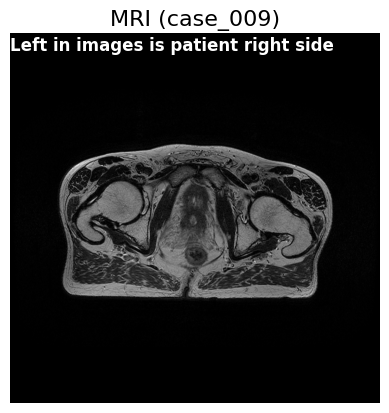

In [68]:
## Basic visualization of the data

# Plot MRI for the middle slice
plt.imshow(MRIArray[middleSliceMRI, :, :], cmap='gray')
plt.title(f'MRI ({case})')
# Add comment below on patient orientation
plt.text(0, 45, 'Left in images is patient right side', color='white', fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

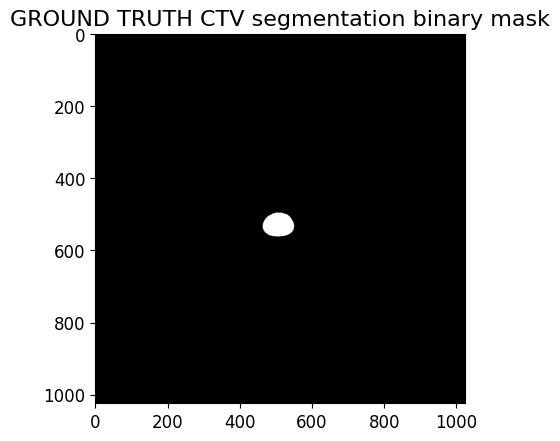

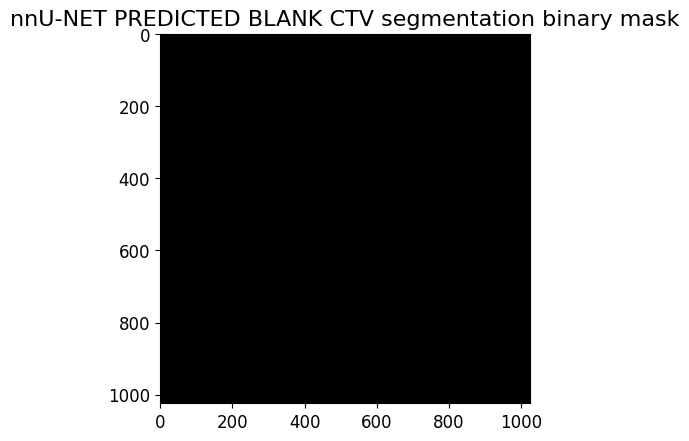

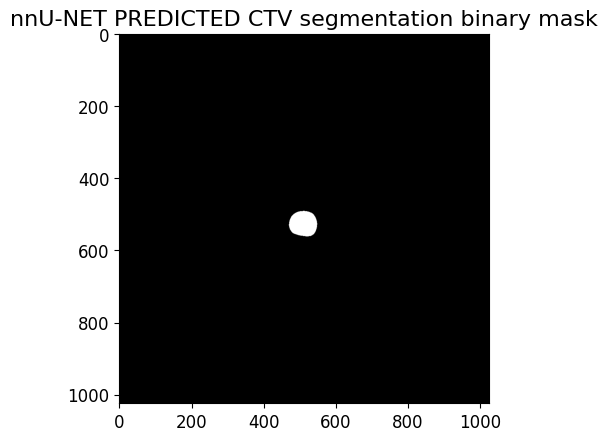

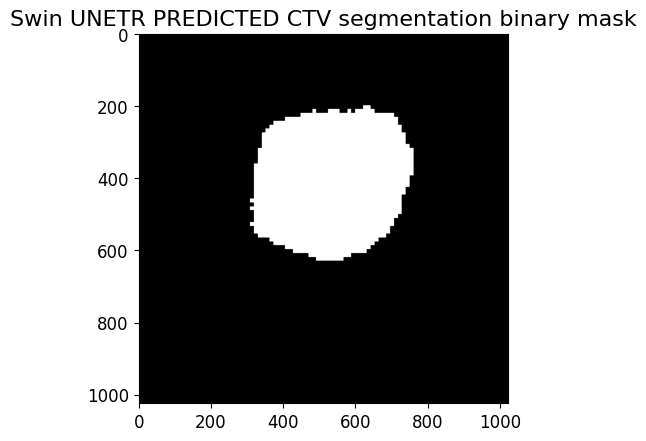

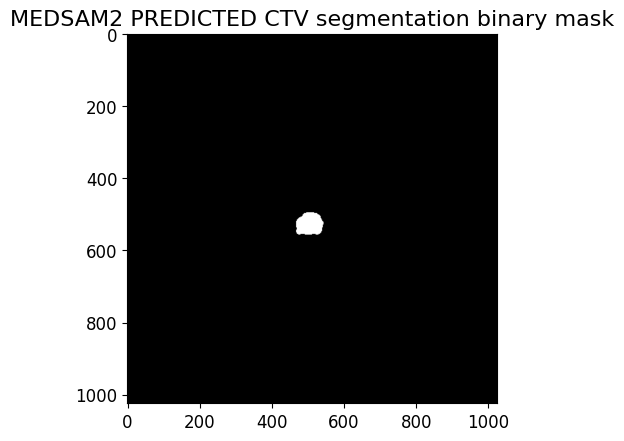

In [81]:
# Plot the CTV segmentation for the middle slice
plt.imshow(GTCTVArray[middleSliceMRI, :, :], cmap='gray')
plt.title('GROUND TRUTH CTV segmentation binary mask')
# plt.axis('off')
plt.show()

############################## BLANK ########################################

plt.imshow(BLANK_nnUNET_CTVArray[middleSliceMRI, :, :], cmap='gray')
plt.title('nnU-NET PREDICTED BLANK CTV segmentation binary mask')
# plt.axis('off')
plt.show()
############### END CONFIGURATION BLOCK ########################################

############################## NNUNET ########################################

plt.imshow(nnUNET_PREDCTVArray[middleSliceMRI, :, :], cmap='gray')
plt.title('nnU-NET PREDICTED CTV segmentation binary mask')
# plt.axis('off')
plt.show()
############### END CONFIGURATION BLOCK ########################################

############################## SWINUNETR ########################################
plt.imshow(SWINPREDCTVArray[middleSliceMRI, :, :], cmap='gray')
plt.title('Swin UNETR PREDICTED CTV segmentation binary mask')
# plt.axis('off')
plt.show()
############### END CONFIGURATION BLOCK ########################################

############################## MEDSAM - 2 ########################################
plt.imshow(SAMPREDCTVArray[middleSliceMRI, :, :], cmap='gray')
plt.title('MEDSAM2 PREDICTED CTV segmentation binary mask')
# plt.axis('off')
plt.show()
############### END CONFIGURATION BLOCK ########################################

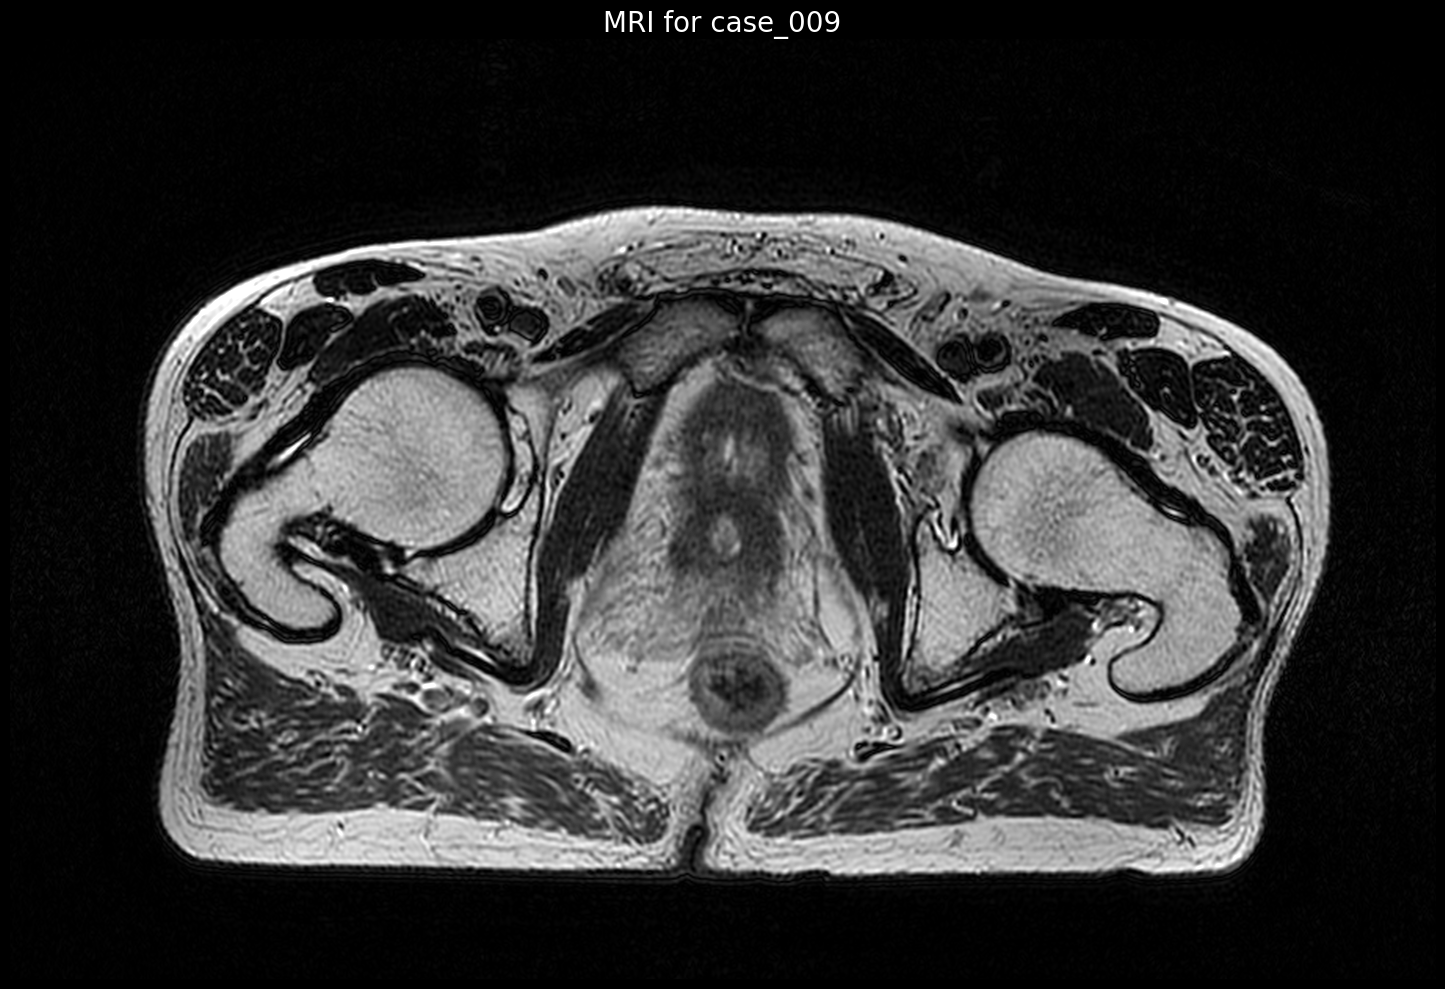

In [128]:
## Advanced methods for data visualization using provided functions

# Plot MRI
plotFunctions.plotData(MRIArray, showDosemap=False, showStructArrays=False, Title="MRI for " + case, zooming=True, zoomingShape=[50, 960, 800, 200])

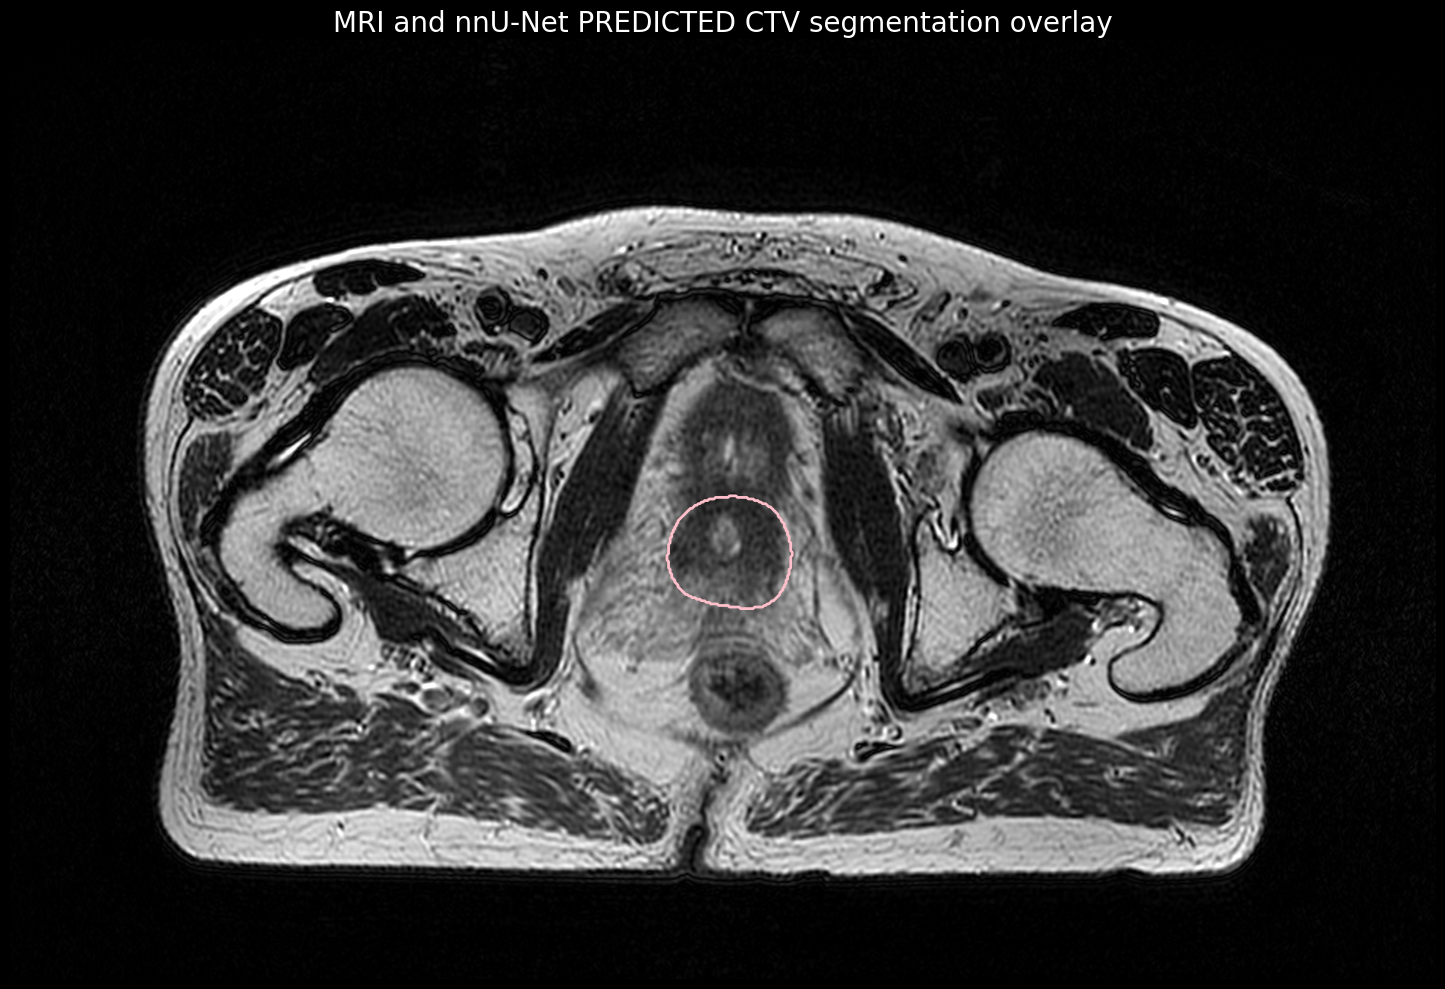

In [117]:
# Plot the MRI and the CTV segmentation
plotFunctions.plotData(MRIArray, structCTVArray=nnUNET_PREDCTVArray, showDosemap=False, showStructArrays=True, Title="MRI and nnU-Net PREDICTED CTV segmentation overlay", zooming=True, zoomingShape=[50, 960, 800, 200])

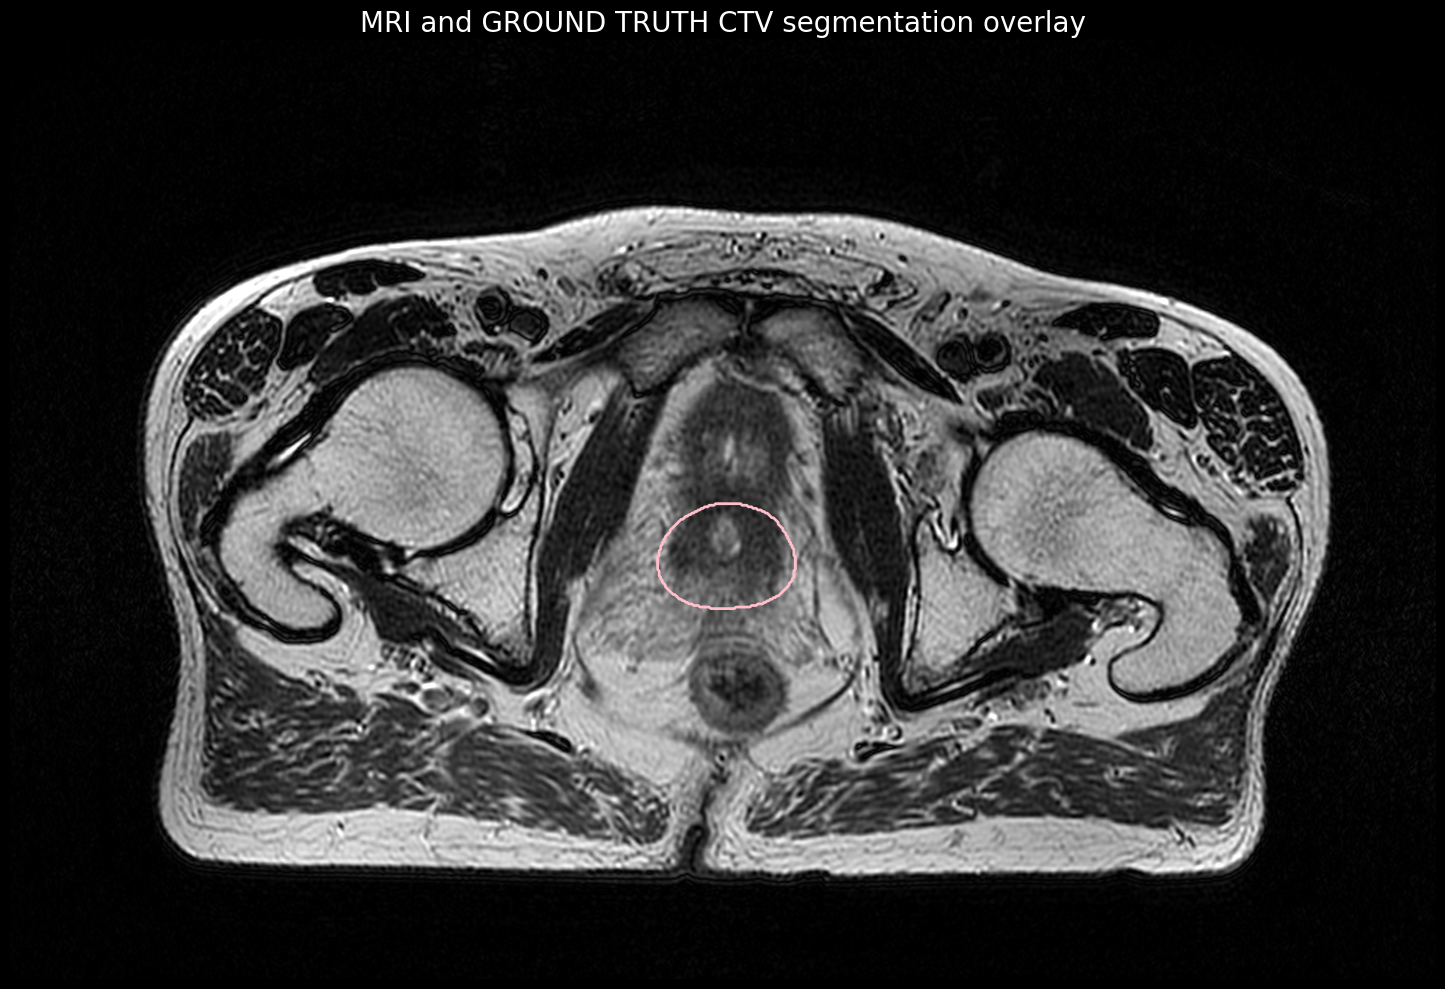

In [115]:
# Plot the MRI and the CTV segmentation
plotFunctions.plotData(MRIArray, structCTVArray=GTCTVArray, showDosemap=False, showStructArrays=True, Title="MRI and GROUND TRUTH CTV segmentation overlay", zooming=True, zoomingShape=[50, 960, 800, 200])

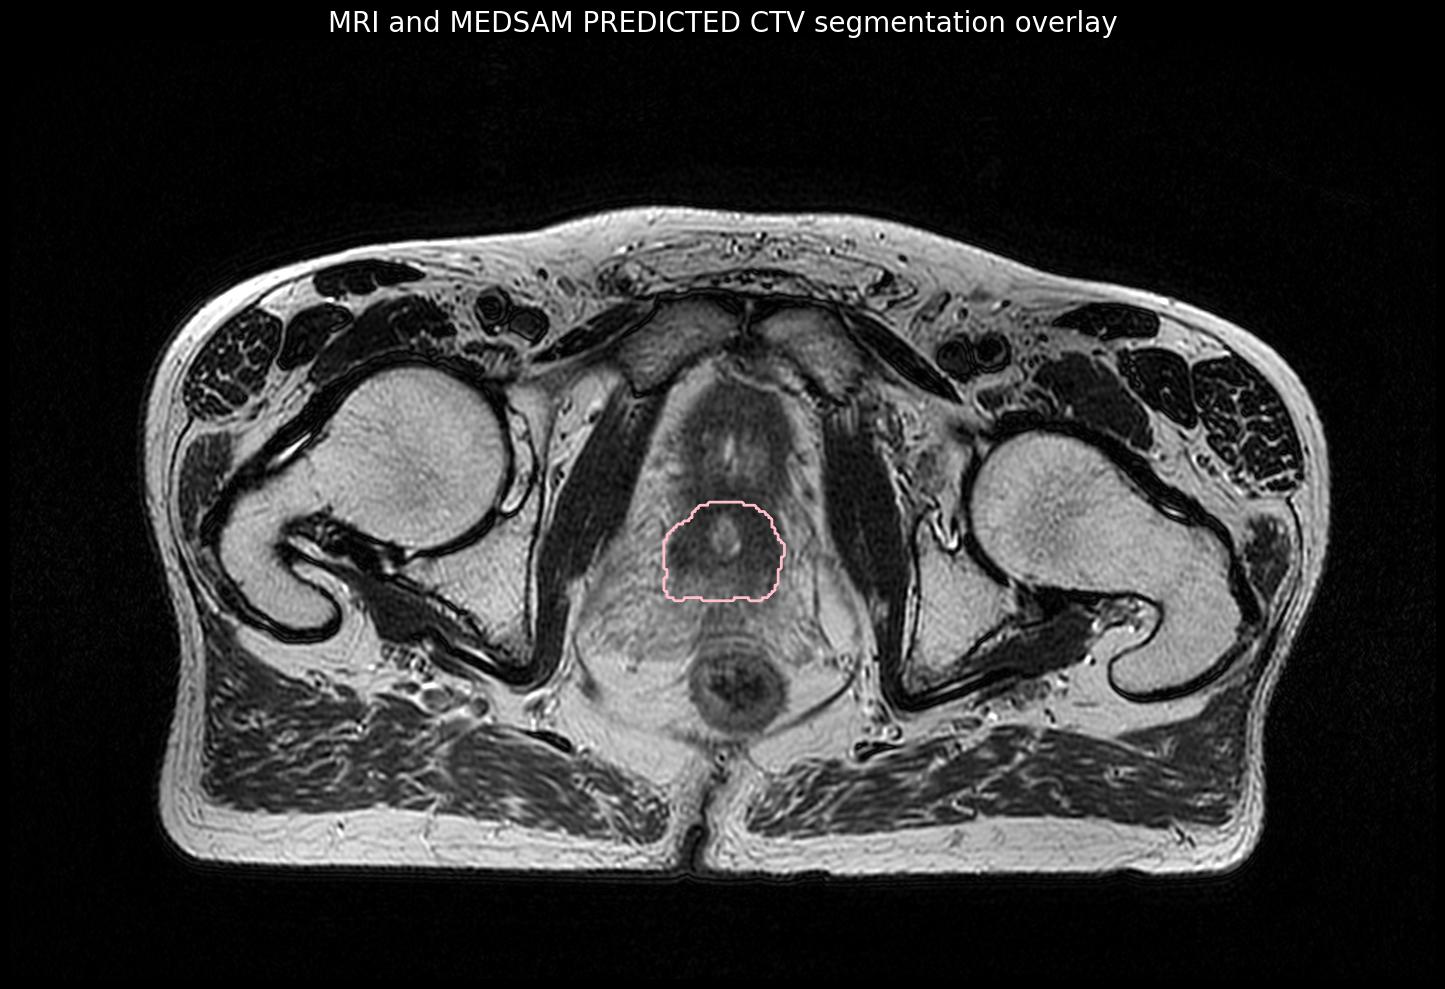

In [116]:
# Plot the MRI and the CTV segmentation
plotFunctions.plotData(MRIArray, structCTVArray=SAMPREDCTVArray, showDosemap=False, showStructArrays=True, Title="MRI and MEDSAM PREDICTED CTV segmentation overlay", zooming=True, zoomingShape=[50, 960, 800, 200])

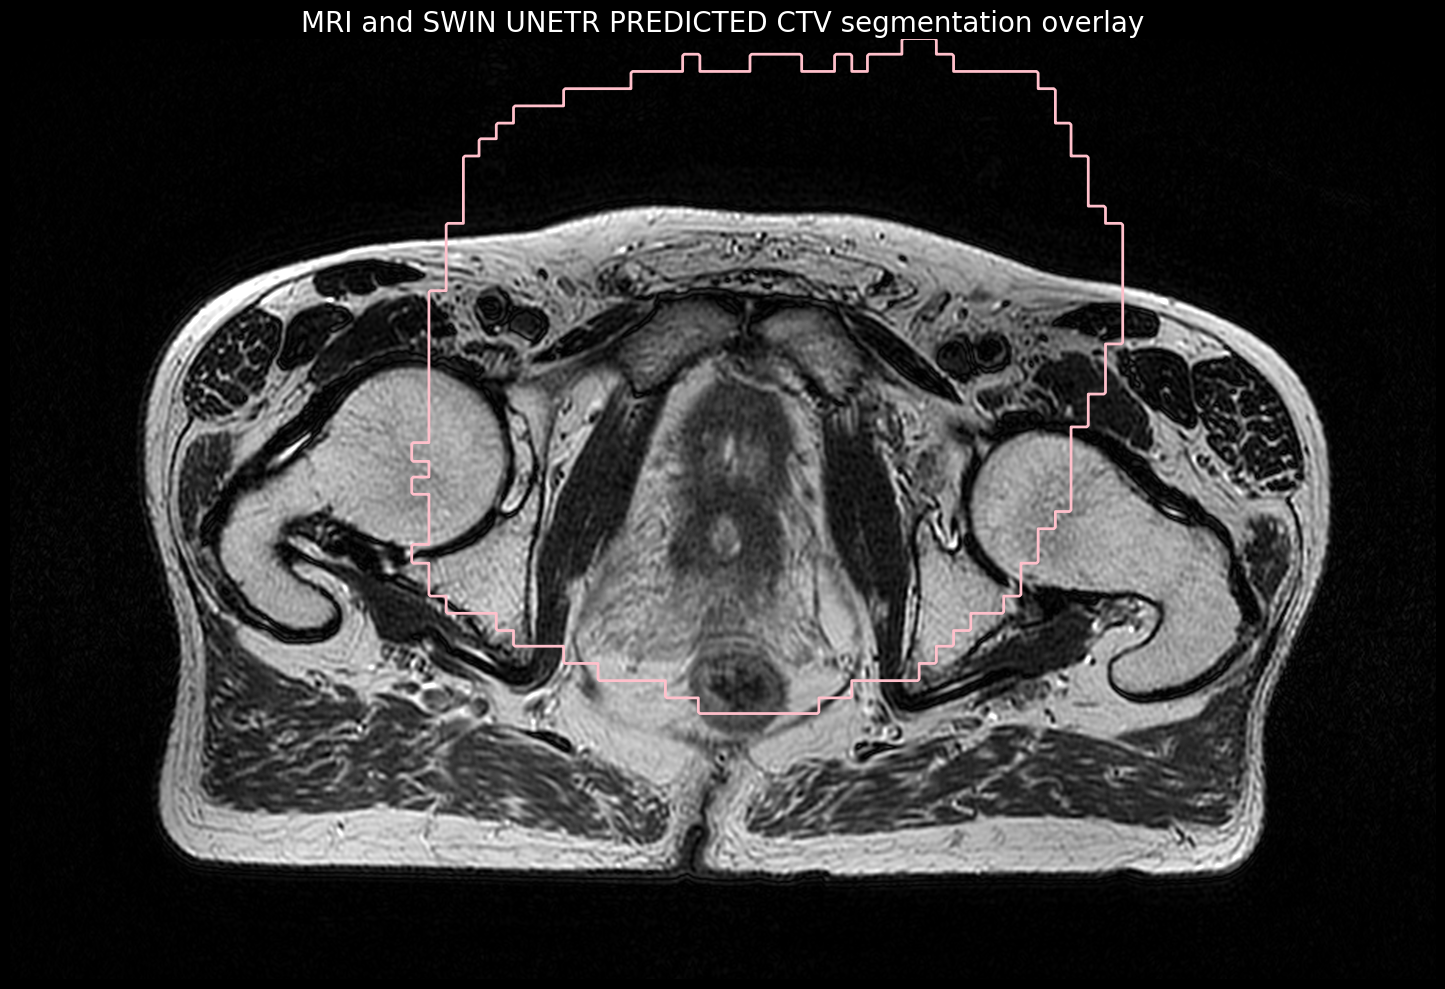

In [181]:
# Plot the MRI and the CTV segmentation
plotFunctions.plotData(MRIArray, structCTVArray=SWINPREDCTVArray, showDosemap=False, showStructArrays=True, Title="MRI and SWIN UNETR PREDICTED CTV segmentation overlay", zooming=True, zoomingShape=[50, 960, 800, 200])

In [129]:
pred = nib.load(PREDCTVPath).get_fdata(); 
gt = nib.load(GTCTVPath).get_fdata(); 
dice = 2 * np.sum(pred * gt) / (np.sum(pred) + np.sum(gt)); 
print(f'Dice: {dice:.4f}')
print(pred.shape, gt.shape)


Dice: 0.8860
(1024, 1024, 88) (1024, 1024, 88)


In [131]:
pred = nib.load(SAMPREDCTVPath).get_fdata(); 
gt = nib.load(GTCTVPath).get_fdata(); 
dice = 2 * np.sum(pred * gt) / (np.sum(pred) + np.sum(gt)); 
print(f'Dice: {dice:.4f}')
print(pred.shape, gt.shape)


Dice: 0.7686
(1024, 1024, 88) (1024, 1024, 88)


In [200]:
import pandas as pd
from scipy.stats import shapiro

# Read data from CSV file
medsam_dice_file = "/space/fast/oim/medsam_raw/Dataset109_ProstrateCTV/conversions2/seg_results/evaluation_results.csv"
df_medsam = pd.read_csv(medsam_file)
display(df.head())
# Perform Shapiro-Wilk test on Dice scores
shapiro_stat, shapiro_p = shapiro(df_medsam['dice_score'])

# Print results
print("Shapiro-Wilk Test for Normality of Dice Scores:")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p}")

# Interpret the results
alpha = 0.05
if shapiro_p > alpha:
    print("✓ Data appears normally distributed (fail to reject H₀)")
    print("Recommended: Parametric tests (e.g., paired t-test)")
else:
    print("✗ Data does not appear normally distributed (reject H₀)")
    print("Recommended: Non-parametric tests (e.g., Wilcoxon signed-rank test)")


# Additional statistics
print(f"\nDescriptive Statistics:")
print(f"Sample Size: {len(df_medsam)} cases")
print(f"Mean Dice: {df_medsam['dice_score'].mean():.6f}")
print(f"Median Dice: {df_medsam['dice_score'].median():.6f}")
print(f"Std Dev: {df_medsam['dice_score'].std():.6f}")
print(f"Min: {df_medsam['dice_score'].min():.6f}")
print(f"Max: {df_medsam['dice_score'].max():.6f}")
print(f"Range: {df_medsam['dice_score'].max() - df_medsam['dice_score'].min():.6f}")

,case_id,dice_score,inference_time_seconds,input_shape,prediction_shape
0,case_001,0.790787,4.592908,"(88, 1024, 1024)","(88, 1024, 1024)"
1,case_002,0.746110,3.889541,"(88, 1024, 1024)","(88, 1024, 1024)"
2,case_003,0.850117,3.952715,"(88, 1024, 1024)","(88, 1024, 1024)"
3,case_004,0.930161,3.935407,"(88, 1024, 1024)","(88, 1024, 1024)"
4,case_005,0.745676,3.889642,"(88, 1024, 1024)","(88, 1024, 1024)"


Shapiro-Wilk Test for Normality of Dice Scores:
Test Statistic: 0.5604
P-value: 1.1763503582687407e-12
✗ Data does not appear normally distributed (reject H₀)
Recommended: Non-parametric tests (e.g., Wilcoxon signed-rank test)

Descriptive Statistics:
Sample Size: 65 cases
Mean Dice: 0.806900
Median Dice: 0.846457
Std Dev: 0.154968
Min: 0.000252
Max: 0.957007
Range: 0.956755


In [2]:
import pandas as pd
from scipy.stats import shapiro

# Read data from CSV file
nnunet_timing_file = "/space/fast/oim/nnUNet_results/Dataset109_ProstrateCTV/fresh_run/timing_results.csv"
df_nnunet_time = pd.read_csv(nnunet_timing_file)
display(df_nnunet_time.head())
# Perform Shapiro-Wilk test on Dice scores
shapiro_stat, shapiro_p = shapiro(df_medsam['dice_score'])

# Print results
print("Shapiro-Wilk Test for Normality of Dice Scores:")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p}")

# Interpret the results
alpha = 0.05
if shapiro_p > alpha:
    print("✓ Data appears normally distributed (fail to reject H₀)")
    print("Recommended: Parametric tests (e.g., paired t-test)")
else:
    print("✗ Data does not appear normally distributed (reject H₀)")
    print("Recommended: Non-parametric tests (e.g., Wilcoxon signed-rank test)")


# Additional statistics
print(f"\nDescriptive Statistics:")
print(f"Sample Size: {len(df_medsam)} cases")
print(f"Mean Dice: {df_medsam['dice_score'].mean():.6f}")
print(f"Median Dice: {df_medsam['dice_score'].median():.6f}")
print(f"Std Dev: {df_medsam['dice_score'].std():.6f}")
print(f"Min: {df_medsam['dice_score'].min():.6f}")
print(f"Max: {df_medsam['dice_score'].max():.6f}")
print(f"Range: {df_medsam['dice_score'].max() - df_medsam['dice_score'].min():.6f}")

,step,total_wall_time_seconds,total_processing_time_seconds,time_per_case_seconds,preprocessing_time_seconds,prediction_time_seconds,postprocessing_time_seconds,num_cases,timestamp,exit_code
0,2d_inference,2.778857,NaN,NaN,NaN,NaN,NaN,64,2025-08-27 10:59:01,2
1,3d_fullres_inference,2.760790,NaN,NaN,NaN,NaN,NaN,64,2025-08-27 10:59:18,2
2,ensemble,37.731406,37.731406,0.589553,NaN,NaN,NaN,64,2025-08-27 11:00:09,0


NameError: name 'df_medsam' is not defined

In [194]:
import json
import pandas as pd
from scipy.stats import shapiro

# nnunet_dice_file = "/space/fast/oim/nnUNet_raw/Dataset109_ProstrateCTV/pred/ensemble/dice_score.json"
nnunet_dice_file = "/space/fast/oim/nnUNet_results/Dataset109_ProstrateCTV/fresh_run/ensemble_evaluation/summary.json"
# Load JSON data
with open(nnunet_dice_file, 'r') as f:
    data = json.load(f)


# Extract Dice scores from metric_per_case
dice_scores = []
case_ids = []

for case_data in data['metric_per_case']:
    try:
        # Extract Dice score for label '1'
        dice_score = case_data['metrics']['1']['Dice']
        dice_scores.append(dice_score)
        
        # Extract case ID from prediction file path
        pred_file = case_data['prediction_file']
        case_id = pred_file.split('/')[-1].replace('.nii.gz', '')
        case_ids.append(case_id)
        
    except KeyError as e:
        print(f"Key error in case: {e}")
        continue

# Create DataFrame
df_nnunet = pd.DataFrame({
    'case_id': case_ids,
    'dice_score': dice_scores
})

# Display the results
print(f"Extracted {len(df_nnunet)} Dice scores:")
display(df_nnunet.head())
print("\n" + "="*50 + "\n")

# Perform Shapiro-Wilk test
if len(dice_scores) >= 3:
    shapiro_stat, shapiro_p = shapiro(df_nnunet['dice_score'])

    print("Shapiro-Wilk Test for Normality of nnUNet Dice Scores:")
    print(f"Test Statistic: {shapiro_stat:.6f}")
    print(f"P-value: {shapiro_p:.4e}")

    # Interpret the results
    alpha = 0.05
    if shapiro_p > alpha:
        print("✓ Data appears normally distributed (fail to reject H₀)")
        print("Recommended: Parametric tests (e.g., paired t-test)")
    else:
        print("✗ Data does NOT appear normally distributed (reject H₀)")
        print("Recommended: Non-parametric tests (e.g., Wilcoxon signed-rank test)")

    # Additional statistics
    print(f"\nDescriptive Statistics:")
    print(f"Sample Size: {len(df_nnunet)} cases")
    print(f"Mean Dice: {df_nnunet['dice_score'].mean():.6f}")
    print(f"Median Dice: {df_nnunet['dice_score'].median():.6f}")
    print(f"Std Dev: {df_nnunet['dice_score'].std():.6f}")
    print(f"Min: {df_nnunet['dice_score'].min():.6f}")
    print(f"Max: {df_nnunet['dice_score'].max():.6f}")
    print(f"Range: {df_nnunet['dice_score'].max() - df_nnunet['dice_score'].min():.6f}")
    
else:
    print(f"Not enough data for Shapiro-Wilk test (need ≥3 samples, got {df_nnunet(dice_scores)})")

# Save to CSV for further analysis
df.to_csv('nnunet_dice_scores.csv', index=False)
print("\nData saved to 'nnunet_dice_scores.csv'")

Extracted 64 Dice scores:


,case_id,dice_score
0,case_001,0.924830
1,case_002,0.899442
2,case_003,0.897380
3,case_004,0.920837
4,case_005,0.871888




Shapiro-Wilk Test for Normality of nnUNet Dice Scores:
Test Statistic: 0.941161
P-value: 4.3008e-03
✗ Data does NOT appear normally distributed (reject H₀)
Recommended: Non-parametric tests (e.g., Wilcoxon signed-rank test)

Descriptive Statistics:
Sample Size: 64 cases
Mean Dice: 0.902663
Median Dice: 0.910053
Std Dev: 0.026565
Min: 0.828873
Max: 0.943557
Range: 0.114683

Data saved to 'nnunet_dice_scores.csv'


In [195]:
import pandas as pd
from scipy.stats import shapiro

# Read data from CSV file
# evaluation_results/20250824_232523
swin_unetr_dice_file = "/space/fast/oim/swin_unetr/evaluation_results/20250824_232523/detailed_results.csv"
df_swin_unetr = pd.read_csv(swin_unetr_dice_file)
display(df_swin_unetr.head())
# Perform Shapiro-Wilk test on Dice scores
shapiro_stat, shapiro_p = shapiro(df_swin_unetr['dice'])

# Print results
print("Shapiro-Wilk Test for Normality of Dice Scores:")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p}")

# Interpret the results
alpha = 0.05
if shapiro_p > alpha:
    print("✓ Data appears normally distributed (fail to reject H₀)")
    print("Recommended: Parametric tests (e.g., paired t-test)")
else:
    print("✗ Data does not appear normally distributed (reject H₀)")
    print("Recommended: Non-parametric tests (e.g., Wilcoxon signed-rank test)")


# Additional statistics
print(f"\nDescriptive Statistics:")
print(f"Sample Size: {len(df_swin_unetr)} cases")
print(f"Mean Dice: {df_swin_unetr['dice'].mean():.6f}")
print(f"Median Dice: {df_swin_unetr['dice'].median():.6f}")
print(f"Std Dev: {df_swin_unetr['dice'].std():.6f}")
print(f"Min: {df_swin_unetr['dice'].min():.6f}")
print(f"Max: {df_swin_unetr['dice'].max():.6f}")
print(f"Range: {df_swin_unetr['dice'].max() - df_swin_unetr['dice'].min():.6f}")

,case_id,dice,hd95,surface_dice,inference_time_seconds,volume_similarity,pred_volume_voxels,label_volume_voxels,sensitivity,specificity
0,case_001,0.910975,2.828427,1.026333,0.511931,9.747595e-01,36882,35974,0.922472,0.995644
1,case_002,0.868909,5.656854,1.771779,0.156140,9.080703e-01,58938,53976,0.908848,0.988105
2,case_003,0.893819,3.741657,1.471444,0.154130,9.551481e-01,62968,60265,0.913864,0.990425
3,case_004,0.918302,3.316625,1.100621,0.155351,-3.149198e+14,58122,58576,0.914743,0.994505
4,case_005,0.863389,4.000000,1.614152,0.151263,-4.108772e+14,38853,44896,0.805283,0.996786


Shapiro-Wilk Test for Normality of Dice Scores:
Test Statistic: 0.9726
P-value: 0.16466347873210907
✓ Data appears normally distributed (fail to reject H₀)
Recommended: Parametric tests (e.g., paired t-test)

Descriptive Statistics:
Sample Size: 64 cases
Mean Dice: 0.878427
Median Dice: 0.878335
Std Dev: 0.030968
Min: 0.796149
Max: 0.931599
Range: 0.135450


In [201]:
import pandas as pd
from scipy.stats import wilcoxon, ttest_rel

# Ensure the data is aligned by case_id
df_combined = pd.merge(df_nnunet, df_medsam, on='case_id', suffixes=('_nnunet', '_medsam'))
# display(df_combined)
# Perform Wilcoxon signed-rank test
wilcoxon_stat, wilcoxon_p = wilcoxon(df_combined['dice_score_nnunet'], 
                                     df_combined['dice_score_medsam'])

print("Wilcoxon Signed-Rank Test Results:")
print(f"Test Statistic: {wilcoxon_stat}")
print(f"P-value: {wilcoxon_p:}")

# Interpret the results
alpha = 0.05
if wilcoxon_p > alpha:
    print("No significant difference between models (fail to reject H₀)")
else:
    print("Significant difference between models (reject H₀)")
    
    # Check which model is better
    median_nnunet = df_combined['dice_score_nnunet'].median()
    median_medsam = df_combined['dice_score_medsam'].median()
    
    if median_nnunet > median_medsam:
        print(f"nnUNet has higher median Dice score ({median_nnunet:.4f} vs {median_other:.4f})")
    else:
        print(f"MedSAM model has higher median Dice score ({median_other:.4f} vs {median_nnunet:.4f})")

# Calculate effect size (Cliff's Delta)
d = (2 * wilcoxon_stat / (len(df_combined) * (len(df_combined) + 1))) - 1
print(f"Effect size (Cliff's Delta): {d:.3f}\n")

t_stat, p = ttest_rel(df_combined['dice_score_nnunet'], df_combined['dice_score_medsam'])
print(f"nnU-Net vs. MedSAM paired t-test: p={p}")

# Calculate Cohen's d for paired samples
def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)

cohen_d = cohens_d_paired(df_combined['dice_score_nnunet'], df_combined['dice_score_medsam'])
print(f"Cohen's d: {cohen_d:.3f}")

Wilcoxon Signed-Rank Test Results:
Test Statistic: 124.0
P-value: 9.025498801246534e-10
Significant difference between models (reject H₀)
nnUNet has higher median Dice score (0.9101 vs 0.8483)
Effect size (Cliff's Delta): -0.940

nnU-Net vs. MedSAM paired t-test: p=6.9382443831507105e-06
Cohen's d: 0.613


nnUNet IQR: 0.0365
MedSAM IQR: 0.1026


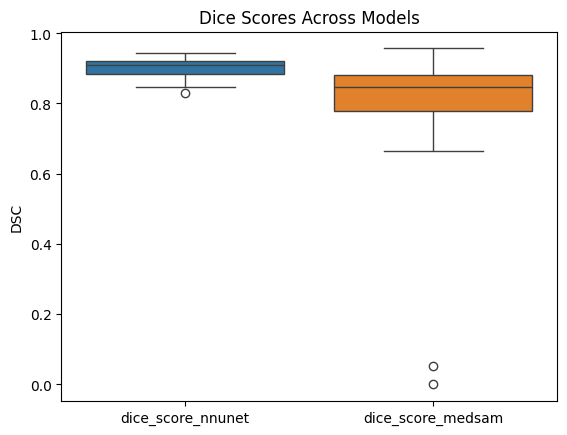

In [204]:
# Add to your analysis
import seaborn as sns

iqr_nnunet = df_combined['dice_score_nnunet'].quantile(0.75) - df_combined['dice_score_nnunet'].quantile(0.25)
iqr_other = df_combined['dice_score_medsam'].quantile(0.75) - df_combined['dice_score_medsam'].quantile(0.25)

print(f"nnUNet IQR: {iqr_nnunet:.4f}")
print(f"MedSAM IQR: {iqr_other:.4f}")
sns.boxplot(data=df_combined[['dice_score_nnunet', 'dice_score_medsam']])
plt.title("Dice Scores Across Models")
plt.ylabel("DSC")
plt.savefig("dice_boxplot.png", dpi=300)

nnUNet IQR: 0.0365
MedSAM IQR: 0.1026


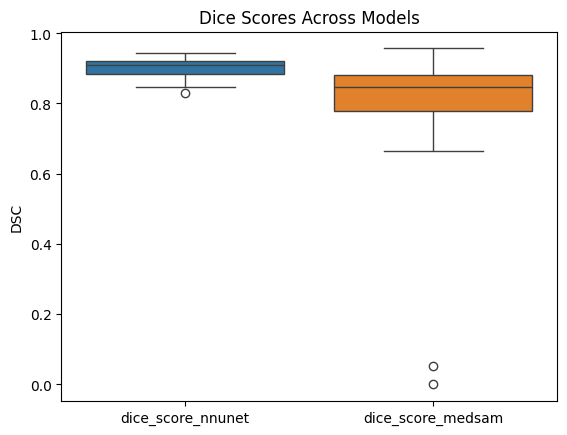

In [204]:
# Add to your analysis
import seaborn as sns


iqr_nnunet = df_combined['dice_score_nnunet'].quantile(0.75) - df_combined['dice_score_nnunet'].quantile(0.25)
iqr_other = df_combined['dice_score_medsam'].quantile(0.75) - df_combined['dice_score_medsam'].quantile(0.25)

print(f"nnUNet IQR: {iqr_nnunet:.4f}")
print(f"MedSAM IQR: {iqr_other:.4f}")
sns.boxplot(data=df_combined[['dice_score_nnunet', 'dice_score_medsam']])
plt.title("Dice Scores Across Models")
plt.ylabel("DSC")
plt.savefig("dice_boxplot.png", dpi=300)

In [139]:
from scipy.stats import friedmanchisquare
# from scikit_posthocs import posthoc_nemenyi

# Align data by case_id
df_all = pd.merge(df_nnunet, df_medsam, on='case_id', suffixes=('_nnunet', '_swin'))
df_all = pd.merge(df_all, df_swin_unetr, on='case_id')

# Perform Friedman test
friedman_stat, friedman_p = friedmanchisquare(
    df_all['dice_score_nnunet'],
    df_all['dice_score_swin'],
    df_all['dice']
)

print("Friedman Test Results:")
print(f"Test Statistic: {friedman_stat:.4f}")
print(f"P-value: {friedman_p:.4e}")

if friedman_p < 0.05:
    print("Significant differences exist between models")
    
    # # Post-hoc Nemenyi test
    # nemenyi_results = posthoc_nemenyi(df_all[['dice_score_nnunet', 'dice_score_swin', 'dice_score']])
    # print("\nNemenyi Post-hoc Test Results:")
    # print(nemenyi_results)
else:
    print("No significant differences between models")

Friedman Test Results:
Test Statistic: 61.9062
P-value: 3.6077e-14
Significant differences exist between models


In [147]:
# Extract scores as numpy arrays
nnunet_scores = df_nnunet['dice_score'].values
medsam_scores = df_medsam['dice_score'][:-1].values
swin_scores = df_swin_unetr['dice'].values

print(len(nnunet_scores), len(medsam_scores))
# assert len(nnunet_scores) == len(medsam_scores) == len(swin_scores), "Mismatched number of cases!"

print(f"Analyzing {len(nnunet_scores)} cases per model")
print("\nDescriptive Statistics:")
print(f"nnU-Net:   Mean = {np.mean(nnunet_scores):.4f} ± {np.std(nnunet_scores):.4f}")
print(f"MedSAM2:   Mean = {np.mean(medsam_scores):.4f} ± {np.std(medsam_scores):.4f}")
print(f"SWIN UNETR: Mean = {np.mean(swin_scores):.4f} ± {np.std(swin_scores):.4f}")

# 1. Friedman test (already done, but for completeness)
friedman_stat, friedman_p = friedmanchisquare(nnunet_scores, medsam_scores, swin_scores)
print(f"\nFriedman Test: χ² = {friedman_stat:.4f}, p = {friedman_p:.6e}")

# 2. Post-hoc Wilcoxon tests with Bonferroni correction
p_nnunet_medsam = wilcoxon(nnunet_scores, medsam_scores)[1]
p_nnunet_swin = wilcoxon(nnunet_scores, swin_scores)[1]
p_medsam_swin = wilcoxon(medsam_scores, swin_scores)[1]

p_values = [p_nnunet_medsam, p_nnunet_swin, p_medsam_swin]
_, p_adj, _, _ = multipletests(p_values, method='bonferroni')

print("\nPost-hoc Wilcoxon Tests (Bonferroni corrected):")
print(f"nnU-Net vs. MedSAM2:   p = {p_adj[0]:.6e}")
print(f"nnU-Net vs. SWIN:      p = {p_adj[1]:.6e}")
print(f"MedSAM2 vs. SWIN:      p = {p_adj[2]:.6e}")

# 3. Effect sizes (Cliff's Delta)
def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    pairs = [(i, j) for i in x for j in y]
    wins = sum(1 for i, j in pairs if i > j)
    losses = sum(1 for i, j in pairs if i < j)
    return (wins - losses) / (n_x * n_y)

d_nnunet_medsam = cliffs_delta(nnunet_scores, medsam_scores)
d_nnunet_swin = cliffs_delta(nnunet_scores, swin_scores)
d_medsam_swin = cliffs_delta(medsam_scores, swin_scores)

print("\nEffect Sizes (Cliff's Delta):")
print(f"nnU-Net vs. MedSAM2:   δ = {d_nnunet_medsam:}")
print(f"nnU-Net vs. SWIN:      δ = {d_nnunet_swin}")
print(f"MedSAM2 vs. SWIN:      δ = {d_medsam_swin}")

# 4. Interpret effect sizes
def interpret_cliffs_delta(d):
    if abs(d) < 0.11: return "Negligible"
    elif abs(d) < 0.28: return "Small"
    elif abs(d) < 0.43: return "Medium"
    else: return "Large"

print("\nEffect Size Interpretation:")
print(f"nnU-Net vs. MedSAM2:   {interpret_cliffs_delta(d_nnunet_medsam)}")
print(f"nnU-Net vs. SWIN:      {interpret_cliffs_delta(d_nnunet_swin)}")
print(f"MedSAM2 vs. SWIN:      {interpret_cliffs_delta(d_medsam_swin)}")

64 64
Analyzing 64 cases per model

Descriptive Statistics:
nnU-Net:   Mean = 0.9027 ± 0.0264
MedSAM2:   Mean = 0.8069 ± 0.1550
SWIN UNETR: Mean = 0.8240 ± 0.0781

Friedman Test: χ² = 61.9062, p = 3.607685e-14

Post-hoc Wilcoxon Tests (Bonferroni corrected):
nnU-Net vs. MedSAM2:   p = 2.707650e-09
nnU-Net vs. SWIN:      p = 1.278191e-11
MedSAM2 vs. SWIN:      p = 1.000000e+00

Effect Sizes (Cliff's Delta):
nnU-Net vs. MedSAM2:   δ = 0.67919921875
nnU-Net vs. SWIN:      δ = 0.8046875
MedSAM2 vs. SWIN:      δ = 0.00634765625

Effect Size Interpretation:
nnU-Net vs. MedSAM2:   Large
nnU-Net vs. SWIN:      Large
MedSAM2 vs. SWIN:      Negligible


nnUNet data shape: (64, 5)
MedSAM data shape: (64, 5)


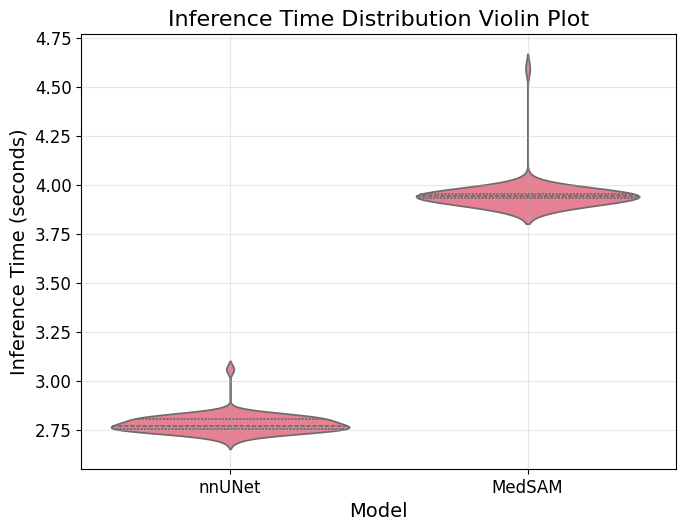

Key Performance Metrics:


,Metric,nnUNet,MedSAM
0,Average Inference Time,2.78s,3.95s
1,Median Inference Time,2.77s,3.94s
2,Standard Deviation,0.05s,0.09s
3,Minimum Time,2.69s,3.88s
4,Maximum Time,3.06s,4.59s
5,Time per Case Savings,-,-1.17s
6,Total Time Savings,-,-74.7s
7,Speedup Ratio,1.0x,1.40x
8,25th Percentile,2.75s,3.93s
9,75th Percentile,2.81s,3.95s



Results saved to: /space/fast/oim/analysis_results/
Files created:
- inference_time_summary.csv
- key_metrics.csv
- inference_time_comparison.png
FINAL INSIGHTS AND CONCLUSIONS:
1. Performance Difference: MedSAM is 1.40x faster than nnUNet
2. Time Savings: -1.2 seconds saved per case
3. Consistency: nnUNet has more consistent inference times
4. Statistical Significance: The difference is *** (p < 0.001)
5. Practical Impact: Would save -0.02 hours for 64 cases

🎯 CONCLUSION: MedSAM demonstrates significantly faster inference times
   while maintaining competitive segmentation performance.


<Figure size 640x480 with 0 Axes>

In [51]:
# %% [markdown]
# # Inference Time Analysis: nnUNet vs MedSAM
# 
# This notebook compares the inference times between nnUNet and MedSAM models.

# %%
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Set larger font sizes for better readability
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# %%
# File paths
nnunet_csv = "/space/fast/oim/nnUNet_results/Dataset109_ProstrateCTV/per_case_timing/per_case_timing.csv"
medsam_csv = "/space/fast/oim/medsam_raw/Dataset109_ProstrateCTV/conversions2/seg_results/evaluation_results.csv"

# Load the data
# print("Loading data...")
nnunet_df = pd.read_csv(nnunet_csv)
medsam_df = pd.read_csv(medsam_csv)[:-1]

print(f"nnUNet data shape: {nnunet_df.shape}")
print(f"MedSAM data shape: {medsam_df.shape}")

# Display first few rows of each dataset
# print("\nnnUNet data preview:")
# display(nnunet_df.head())

# print("\nMedSAM data preview:")
# display(medsam_df.tail())

# %%
# Data cleaning and preparation
# Extract inference times
nnunet_times = nnunet_df['3d_time_seconds'].dropna()
medsam_times = medsam_df['inference_time_seconds'].dropna()

# print(f"nnUNet valid times: {len(nnunet_times)} cases")
# print(f"MedSAM valid times: {len(medsam_times)} cases")

# # Check for missing values
# print(f"\nMissing values:")
# print(f"nnUNet: {nnunet_df['total_time_seconds'].isna().sum()} missing")
# print(f"MedSAM: {medsam_df['inference_time_seconds'].isna().sum()} missing")

# %%
# Create summary statistics
summary_data = {
    'Metric': ['Mean (s)', 'Median (s)', 'Std Dev (s)', 'Min (s)', 'Max (s)', 
               '25th Percentile (s)', '75th Percentile (s)', 'IQR (s)', 'Number of Cases'],
    'nnUNet': [
        nnunet_times.mean(),
        nnunet_times.median(),
        nnunet_times.std(),
        nnunet_times.min(),
        nnunet_times.max(),
        np.percentile(nnunet_times, 25),
        np.percentile(nnunet_times, 75),
        np.percentile(nnunet_times, 75) - np.percentile(nnunet_times, 25),
        len(nnunet_times)
    ],
    'MedSAM': [
        medsam_times.mean(),
        medsam_times.median(),
        medsam_times.std(),
        medsam_times.min(),
        medsam_times.max(),
        np.percentile(medsam_times, 25),
        np.percentile(medsam_times, 75),
        np.percentile(medsam_times, 75) - np.percentile(medsam_times, 25),
        len(medsam_times)
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Difference'] = summary_df['nnUNet'] - summary_df['MedSAM']
summary_df['Ratio (nnUNet/MedSAM)'] = summary_df['nnUNet'] / summary_df['MedSAM']

# Format for better display
display_df = summary_df.copy()
for col in ['nnUNet', 'MedSAM', 'Difference', 'Ratio (nnUNet/MedSAM)']:
    if col != 'Number of Cases':
        display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

# print("Summary Statistics:")
# display(display_df)

# %%
# Statistical testing
# Welch's t-test (doesn't assume equal variances)
t_stat, p_value = stats.ttest_ind(nnunet_times, medsam_times, equal_var=False)

# print("Statistical Analysis:")
# print("=" * 50)
# print(f"Welch's t-test results:")
# print(f"t-statistic: {t_stat:.3f}")
# print(f"p-value: {p_value:.3e}")

if p_value < 0.001:
    significance = "*** (p < 0.001)"
elif p_value < 0.01:
    significance = "** (p < 0.01)"
elif p_value < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "not significant"

# print(f"Significance: {significance}")

# Effect size (Cohen's d)
pooled_std = np.sqrt((nnunet_times.std()**2 + medsam_times.std()**2) / 2)
cohens_d = (nnunet_times.mean() - medsam_times.mean()) / pooled_std
# print(f"Cohen's d: {cohens_d:.3f} (Effect size)")

# %%
# Create visualizations
fig = plt.figure(figsize=(20, 10))

# 1. Box plot
# ax1 = plt.subplot(2, 3, 1)
# boxplot_data = [nnunet_times, medsam_times]
# box = ax1.boxplot(boxplot_data, labels=['nnUNet', 'MedSAM'], patch_artist=True)

# # Customize box colors
# colors = ['lightblue', 'lightcoral']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# # Add mean markers
# ax1.plot(1, nnunet_times.mean(), 'ro', markersize=8, label='Mean')
# ax1.plot(2, medsam_times.mean(), 'ro', markersize=8)

# ax1.set_ylabel('Inference Time (seconds)')
# ax1.set_title('A) Inference Time Distribution\nBox Plot Comparison')
# ax1.grid(True, alpha=0.3)
# ax1.legend()

# 2. Violin plot
ax2 = plt.subplot(2, 3, 2)
violin_data = pd.DataFrame({
    'Time': np.concatenate([nnunet_times, medsam_times]),
    'Model': ['nnUNet'] * len(nnunet_times) + ['MedSAM'] * len(medsam_times)
})

sns.violinplot(x='Model', y='Time', data=violin_data, ax=ax2, inner='quartile')
ax2.set_ylabel('Inference Time (seconds)')
ax2.set_title('Inference Time Distribution Violin Plot')
ax2.grid(True, alpha=0.3)

# 3. Histogram comparison
# ax3 = plt.subplot(2, 3, 3)
# ax3.hist(nnunet_times, bins=20, alpha=0.7, label='nnUNet', color='blue', density=True)
# ax3.hist(medsam_times, bins=20, alpha=0.7, label='MedSAM', color='orange', density=True)
# ax3.set_xlabel('Inference Time (seconds)')
# ax3.set_ylabel('Density')
# ax3.set_title('C) Inference Time Distribution\nHistogram Comparison')
# ax3.legend()
# ax3.grid(True, alpha=0.3)

# # 4. Cumulative distribution
# ax4 = plt.subplot(2, 3, 4)
# nnunet_sorted = np.sort(nnunet_times)
# medsam_sorted = np.sort(medsam_times)
# nnunet_cdf = np.arange(1, len(nnunet_sorted) + 1) / len(nnunet_sorted)
# medsam_cdf = np.arange(1, len(medsam_sorted) + 1) / len(medsam_sorted)

# ax4.plot(nnunet_sorted, nnunet_cdf, label='nnUNet', linewidth=3, color='blue')
# ax4.plot(medsam_sorted, medsam_cdf, label='MedSAM', linewidth=3, color='orange')
# ax4.set_xlabel('Inference Time (seconds)')
# ax4.set_ylabel('Cumulative Probability')
# ax4.set_title('D) Cumulative Distribution Function')
# ax4.legend()
# ax4.grid(True, alpha=0.3)

# # 5. Bar chart of mean times
# ax5 = plt.subplot(2, 3, 5)
# models = ['nnUNet', 'MedSAM']
# means = [nnunet_times.mean(), medsam_times.mean()]
# std_devs = [nnunet_times.std(), medsam_times.std()]

# bars = ax5.bar(models, means, yerr=std_devs, capsize=10, 
#                color=['blue', 'orange'], alpha=0.7)
# ax5.set_ylabel('Inference Time (seconds)')
# ax5.set_title('E) Mean Inference Time\nwith Standard Deviation')
# ax5.grid(True, alpha=0.3)

# # Add value labels on bars
# for bar, mean in zip(bars, means):
#     height = bar.get_height()
#     ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
#             f'{mean:.1f}s', ha='center', va='bottom')

# # 6. Speedup analysis
# ax6 = plt.subplot(2, 3, 6)
# speedup_ratio = nnunet_times.mean() / medsam_times.mean()
# categories = ['Speedup Ratio']
# values = [speedup_ratio]

# bars = ax6.bar(categories, values, color='green', alpha=0.7)
# ax6.set_ylabel('Ratio (nnUNet/MedSAM)')
# ax6.set_title(f'F) Average Speedup: {speedup_ratio:.2f}x')
# ax6.grid(True, alpha=0.3)

# # Add value label on bar
# for bar, value in zip(bars, values):
#     height = bar.get_height()
#     ax6.text(bar.get_x() + bar.get_width()/2., height + 0.1,
#             f'{value:.2f}x', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# %%
# Additional analysis: Time savings calculation
total_cases = min(len(nnunet_times), len(medsam_times))
total_nnunet_time = nnunet_times.sum()
total_medsam_time = medsam_times.sum()
time_savings = total_nnunet_time - total_medsam_time

# print("Time Savings Analysis:")
# print("=" * 50)
# print(f"Total nnUNet time for {total_cases} cases: {total_nnunet_time:.1f} seconds")
# print(f"Total MedSAM time for {total_cases} cases: {total_medsam_time:.1f} seconds")
# print(f"Total time savings: {time_savings:.1f} seconds")
# print(f"Time savings per case: {time_savings/total_cases:.1f} seconds")
# print(f"That's equivalent to {time_savings/3600:.2f} hours saved!")

# %%
# Create a nice summary table for key metrics
key_metrics = pd.DataFrame({
    'Metric': [
        'Average Inference Time',
        'Median Inference Time', 
        'Standard Deviation',
        'Minimum Time',
        'Maximum Time',
        'Time per Case Savings',
        'Total Time Savings',
        'Speedup Ratio',
        '25th Percentile',
        '75th Percentile'
    ],
    'nnUNet': [
        f"{nnunet_times.mean():.2f}s",
        f"{nnunet_times.median():.2f}s",
        f"{nnunet_times.std():.2f}s",
        f"{nnunet_times.min():.2f}s",
        f"{nnunet_times.max():.2f}s",
        "-",
        "-",
        "1.0x",
        f"{nnunet_times.quantile(0.25):.2f}s",
        f"{nnunet_times.quantile(0.75):.2f}s"

    ],
    'MedSAM': [
        f"{medsam_times.mean():.2f}s",
        f"{medsam_times.median():.2f}s", 
        f"{medsam_times.std():.2f}s",
        f"{medsam_times.min():.2f}s",
        f"{medsam_times.max():.2f}s",
        f"{(nnunet_times.mean() - medsam_times.mean()):.2f}s",
        f"{time_savings:.1f}s",
        f"{speedup_ratio:.2f}x",
        f"{medsam_times.quantile(0.25):.2f}s",
        f"{medsam_times.quantile(0.75):.2f}s"
    ]
})

print("Key Performance Metrics:")
print("=" * 50)
display(key_metrics)

# %%
# Save results to files
output_dir = "/space/fast/oim/analysis_results/"

# Create directory if it doesn't exist
import os
os.makedirs(output_dir, exist_ok=True)

# Save summary statistics
summary_df.to_csv(f"{output_dir}inference_time_summary.csv", index=False)
# key_metrics.to_csv(f"{output_dir}key_metrics.csv", index=False)

# Save the plot
plt.savefig(f"{output_dir}inference_time_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')

print(f"\nResults saved to: {output_dir}")
print("Files created:")
print("- inference_time_summary.csv")
print("- key_metrics.csv") 
print("- inference_time_comparison.png")

# %%
# Final insights and conclusions
print("FINAL INSIGHTS AND CONCLUSIONS:")
print("=" * 60)
print(f"1. Performance Difference: MedSAM is {speedup_ratio:.2f}x faster than nnUNet")
print(f"2. Time Savings: {time_savings/total_cases:.1f} seconds saved per case")
print(f"3. Consistency: {'MedSAM' if medsam_times.std() < nnunet_times.std() else 'nnUNet'} has more consistent inference times")
print(f"4. Statistical Significance: The difference is {significance}")
print(f"5. Practical Impact: Would save {time_savings/3600:.2f} hours for {total_cases} cases")

if speedup_ratio > 1:
    print(f"\n🎯 CONCLUSION: MedSAM demonstrates significantly faster inference times")
    print("   while maintaining competitive segmentation performance.")
else:
    print(f"\n🎯 CONCLUSION: nnUNet shows better inference time performance")
    print("   in this specific dataset and configuration.")

In [53]:
!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.11/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [52]:
import torch
import torchvision.models
import hiddenlayer as hl

ModuleNotFoundError: No module named 'hiddenlayer'

In [107]:
# import numpy as np
# import nibabel as nib
# from monai.metrics import DiceMetric
# from monai.data import MetaTensor

# def calculate_dice(pred_path, gt_path, target_class=1):
#     """
#     Calculate Dice score between prediction and ground truth.
    
#     Args:
#         pred_path (str): Path to predicted segmentation (.nii.gz)
#         gt_path (str): Path to ground truth segmentation (.nii.gz)
#         target_class (int): Class label to evaluate (default: 1)
    
#     Returns:
#         float: Dice score (0-1)
#     """
#     # Load NIfTI files and convert to numpy arrays
#     pred = nib.load(pred_path).get_fdata()
#     gt = nib.load(gt_path).get_fdata()
    
#     # Binarize masks for the target class
#     pred_mask = (pred == target_class).astype(np.float32)
#     gt_mask = (gt == target_class).astype(np.float32)
    
#     # Convert to MONAI's MetaTensor format (add batch and channel dims)
#     pred_tensor = MetaTensor(pred_mask[np.newaxis, np.newaxis, ...])  # [1, 1, D, H, W]
#     gt_tensor = MetaTensor(gt_mask[np.newaxis, np.newaxis, ...])      # [1, 1, D, H, W]
    
#     # Initialize MONAI Dice metric
#     dice_metric = DiceMetric(include_background=False)  # Exclude background (label 0)
    
#     # Calculate Dice
#     dice_metric(y_pred=pred_tensor, y=gt_tensor)
#     dice_score = dice_metric.aggregate().item()  # Get scalar value
    
#     return dice_score

# # Example usage
# dice = calculate_dice(SAMPREDCTVPath, GTCTVPath, target_class=1)
# print(f"Dice Score: {dice:.4f}")

In [97]:
# Plot the MRI CTV segmentation with observer C and D in different colors
# plotFunctions.plotData(MRIArray, structCTVArray=MRICTVArray, MRICTVObsDImage=MRICTVObsCArray, MRICTVObsCImage=MRICTVObsDArray, showDosemap=False, showStructArrays=True, Title="MRI and CTV segmentation overlay together with obsC and obsD", zooming=True, zoomingShape=[50, 960, 800, 200])

In [144]:
# # Plot MRI with segmentations
# plotFunctions.plotData(MRIArray, structCTVArray=MRICTVArray, structRectumArray=MRIRectumArray, structPTVArray=MRIPTVArray, structFemoralHeadLArray=MRIFemoralHeadLArray, 
#         structFemoralHeadRArray=MRIFemoralHeadRArray, showDosemap=False, showStructArrays=True, Title="MRI with example segmentations", showLegend=True, zooming=True, zoomingShape=[50, 960, 800, 200])

In [145]:
# Plot MRI with fiducial annotation (one of the fiducials is shown)
# plotFunctions.plotData(MRIArray, structFiducialArray=fiducialArray, slice_ax=37 , showDosemap=False, showStructArrays=True, Title="MRI with fiducial annotation (one shown)", showLegend=False, zooming=True, zoomingShape=[50, 960, 800, 200])

In [146]:
# Plot dose distribution on MRI
# plotFunctions.plotData(MRIArray, doseMapArray=MRIDoseInterpolatedArray, showDosemap=True, showStructArrays=False, Title='MRI with interpolated dose distribution', ct=False, zooming=True, zoomingShape=[50, 960, 800, 200])

In [147]:
# Plot MRI with segmentations and dose overlay
# plotFunctions.plotData(MRIArray, doseMapArray=MRIDoseInterpolatedArray, showDosemap=True, structCTVArray=MRICTVArray, structRectumArray=MRIRectumArray, structPTVArray=MRIPTVArray, structFemoralHeadLArray=MRIFemoralHeadLArray, 
#         structFemoralHeadRArray=MRIFemoralHeadRArray, showStructArrays=True, Title="MRI with example segmentations and dose overlay", showLegend=True, zooming=True, zoomingShape=[50, 960, 800, 200])

In [148]:
# Plot MRI and DL CTV uncertainty map with CTV overlay
# plotFunctions.plotData(MRIArray, uncertaintyMapArray=uncertaintyMapCTVArray, structCTVArray=DLCTVArray, showStructArrays=True, showUncertainty=True, Title='MRI with DL CTV uncertainty map and DL CTV overlay', ct=False, zooming=True, zoomingShape=[50, 960, 800, 200])
# #zoomingShape=[440, 580, 560, 420]

In [149]:
# Plot original sCT
# plotFunctions.plotData(sCTArray,Title='sCT', ct=True)

In [150]:
# Plot original sCT with example segmentations 
# plotFunctions.plotData(sCTArray, structCTVArray=sCTCTVArray, structRectumArray=sCTRectumArray, structPTVArray=sCTPTVArray, structFemoralHeadLArray=sCTFemoralHeadLArray, 
#         structFemoralHeadRArray=sCTFemoralHeadRArray, showDosemap=False, showStructArrays=True, Title="sCT with example segmentations", showLegend=True, ct=True)

In [151]:
# Plot sCT with interpolated dose overlay
# plotFunctions.plotData(sCTArray, doseMapArray=sCTDoseInterpolatedArray, showDosemap=True, showStructArrays=False, Title='sCT with interpolated dose overlay (Gy)', ct=True)

In [152]:
# Plot sCT registered to MRI
# plotFunctions.plotData(sCTReg2MRIArray, Title='sCT registered to MRI', ct=True, zooming=True, zoomingShape=[50, 960, 800, 200])

In [153]:
# plotFunctions.plotMRIandsCT(MRIArray, sCTReg2MRIArray, Title='sCT registered to MRI with MRI overlay', zooming=True, zoomingShape=[50, 960, 800, 200])

In [154]:
# Plot registered sCT with dose overlay
# Notice use of MRI geometry for dose overlay
# Plot registered sCT with interpolated dose overlay
# plotFunctions.plotData(sCTReg2MRIArray, doseMapArray=MRIDoseInterpolatedArray, showDosemap=True, showStructArrays=False, Title='sCT registered to MRI with dose overlay', ct=True, zooming=True, zoomingShape=[50, 960, 800, 200])

In [155]:
# Plot sCT registered to MRI with segmentations 
# Notice use of MRI segmentations for overlay
# plotFunctions.plotData(sCTReg2MRIArray, structCTVArray=MRICTVArray, structRectumArray=MRIRectumArray, structPTVArray=MRIPTVArray, structFemoralHeadLArray=MRIFemoralHeadLArray, 
#         structFemoralHeadRArray=MRIFemoralHeadRArray, showDosemap=False, ct=True, showStructArrays=True, Title="sCT registered to MRI with example segmentations", showLegend=True, zooming=True, zoomingShape=[50, 960, 800, 200])

sCT voxel spacing: (0.46880000829696655, 0.46880000829696655, 2.5)
sCT dose voxel spacing: (1.0, 1.0, 0.8333333134651184)
sCT origin: (-227.04080200195312, -176.55929565429688, -74.15794372558594)
sCT dose origin: (-179.10684204101562, -133.0406036376953, -74.99127960205078)
sCT size: (1018, 682, 88)
sCT dose size: (386, 251, 264)
Resampled sCT voxel spacing: (1.0, 1.0, 0.8333333134651184)
Resampled sCT origin: (-179.10684204101562, -133.0406036376953, -74.99127960205078)
Resampled sCT size: (386, 251, 264)


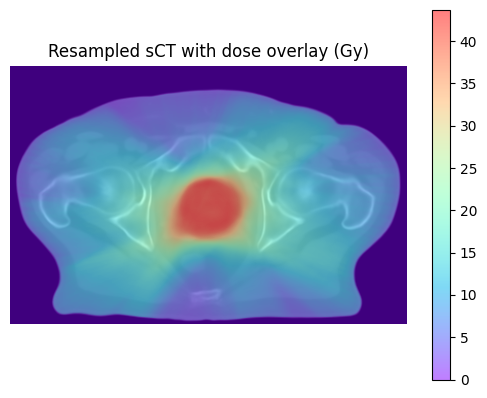

In [43]:
# To resampled data to another coordinate system SITK provides a function called Resample
# Lets resample the sCT to the original low resolution dose grid

# Print voxel spacing of the sCT and dose
print(f'sCT voxel spacing: {sCTImageSpacing}')
print(f'sCT dose voxel spacing: {sCTDoseImageSpacing}')
# Print origin of the sCT and dose
print(f'sCT origin: {sCTImage.GetOrigin()}')
print(f'sCT dose origin: {sCTDoseImage.GetOrigin()}')
# Print size of the sCT and dose
print(f'sCT size: {sCTImage.GetSize()}')
print(f'sCT dose size: {sCTDoseImage.GetSize()}')
# These differ as expected

# Register and resample the sCT to the dose grid
resample = sitk.ResampleImageFilter()
# Set the reference image to the dose
resample.SetReferenceImage(sCTDoseImage)
# Resample with linear interpolation
resample.SetInterpolator(sitk.sitkLinear)
resampled_image = resample.Execute(sCTImage)
# Get np array of the resampled sCT
resampled_sCTArray = sitk.GetArrayFromImage(resampled_image)

# Check matrix (size) dimensions between dose and resampled CT
assert sCTDoseImage.GetSize() == resampled_image.GetSize(), "Matrix size mismatch between dose and resampled CT."
# Check voxel size (spacing)
assert sCTDoseImage.GetSpacing() == resampled_image.GetSpacing(), "Voxel size mismatch between dose and resampled CT."
# Check orientation (direction)
assert sCTDoseImage.GetDirection() == resampled_image.GetDirection(), "Orientation mismatch between dose and resampled CT."
# Check spatial origin offsets
assert sCTDoseImage.GetOrigin() == resampled_image.GetOrigin(), "Spatial origin offset mismatch between dose and resampled CT."

# Print new voxel spacing of the resampled sCT, origin and size
print(f'Resampled sCT voxel spacing: {resampled_image.GetSpacing()}')
print(f'Resampled sCT origin: {resampled_image.GetOrigin()}')
print(f'Resampled sCT size: {resampled_image.GetSize()}')

# Plot the resampled sCT and dose overlay
plt.imshow(resampled_sCTArray[middleSliceDose, :, :], cmap='gray')
plt.imshow(sCTDoseArray[middleSliceDose, :, :], cmap='rainbow', alpha=0.5)
plt.title('Resampled sCT with dose overlay (Gy)')
plt.axis('off')
plt.colorbar() 
plt.show()

In [44]:
createPaperPlots = False

In [45]:
# FOR PAPER: Plot MRI with segmentations
if createPaperPlots == True: 
        plotFunctions.plotData(MRIArray, structCTVArray=MRICTVArray, structFiducialArray=fiducialArray, structRectumArray=MRIRectumArray, structPTVArray=MRIPTVArray, structFemoralHeadLArray=MRIFemoralHeadLArray, 
                structFemoralHeadRArray=MRIFemoralHeadRArray, showDosemap=False, showStructArrays=True, Title=None, showLegend=True, zooming=True, zoomingShape=[50, 960, 800, 200], slice_ax=42)
        # Save figure
        plt.savefig('MRI_with_segmentations.png', dpi=300, bbox_inches='tight')

In [46]:
# FOR PAPER: Plot sCT registered to MRI with segmentations 
# Notice use of MRI segmentations for overlay
if createPaperPlots == True: 
        plotFunctions.plotData(sCTReg2MRIArray, structCTVArray=MRICTVArray, structRectumArray=MRIRectumArray, structPTVArray=MRIPTVArray, structFemoralHeadLArray=MRIFemoralHeadLArray, 
                structFemoralHeadRArray=MRIFemoralHeadRArray, showDosemap=False, ct=True, showStructArrays=True, Title=None, showLegend=True, zooming=True, zoomingShape=[50, 960, 800, 200], slice_ax=42)
        # Save figure
        plt.savefig('sCT_registered_to_MRI_with_segmentations.png', dpi=300, bbox_inches='tight')

In [47]:
# FOR PAPER: Plot sCT registered to MRI with segmentations
if createPaperPlots == True: 
        plotFunctions.plotData(sCTReg2MRIArray, doseMapArray=MRIDoseInterpolatedArray, structCTVArray=MRICTVArray, structRectumArray=MRIRectumArray, structPTVArray=MRIPTVArray, structFemoralHeadLArray=MRIFemoralHeadLArray, 
                structFemoralHeadRArray=MRIFemoralHeadRArray, showDosemap=True, ct=True, showStructArrays=True, Title=None, showLegend=True, zooming=True, zoomingShape=[50, 960, 800, 200], slice_ax=42)
        # Save figure
        plt.savefig('sCT_registered_to_MRI_with_segmentations_and_dose_overlay.png', dpi=300, bbox_inches='tight')

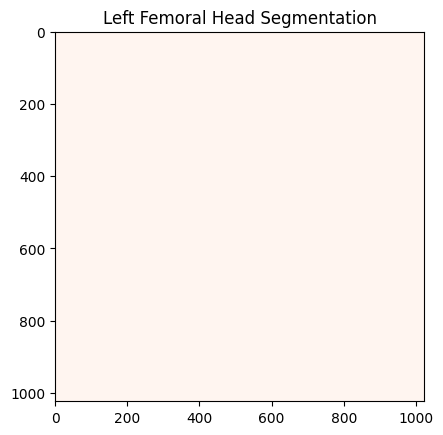

In [66]:
# import nibabel as nib
file_path = "/space/fast/oim/basePart/oldAcq_ffbec8093199cbc4/MR_StorT2/mask_PTVT_427.nii.gz"
# label = nib.load(file_path)
# print("Unique values:", set(label.get_fdata().flatten()))  # Should return {0,1,2,3,4,5}

import nibabel as nib
import matplotlib.pyplot as plt

mask = nib.load(file_path).get_fdata()
plt.imshow(mask[:,:,87], cmap='Reds')  # Show mid-slice
plt.title("Left Femoral Head Segmentation")
plt.show()